# All Steps of Piepline

In [1]:
import sys
import os
import pandas as pd

# Add the project root directory to sys.path
project_root = os.path.abspath("../../")  # Adjust the relative path as needed
if project_root not in sys.path:
    sys.path.append(project_root)

## Bulk download of CRS data

In [ ]:
# Import the necessary functions from src
from src.download_crs import get_full_crs_parquet_url, download_crs_parquet

# Get the full CRS parquet URL
file_url = get_full_crs_parquet_url()

# Download the CRS data
crs = download_crs_parquet(file_url)

In [ ]:
# Save raw CRS to feather 
crs.to_feather("../../data/raw/crs_raw.feather")

## A - Title Pattern Matching 

###  Keyword Detection

In [6]:
from src.text_processing import normalize_str, detect_language, lemmatize_str, lemmatize_batch, detect_keywords, detect_acronyms, process_keywords

In [12]:
detect_keywords("angola statistics project", "en", stat_keywords)

['statistic']

#### Load keywords

In [11]:
import pandas as pd
# Load keywords from Excel file
keywords_file_path = "../../data/keywords/review/keyword_review_modernization.xlsx"
stat_keywords = pd.read_excel(keywords_file_path, sheet_name="statistics")
stat_acronyms = pd.read_excel(keywords_file_path, sheet_name="statistics acronyms")
stat_blacklist = pd.read_excel(keywords_file_path, sheet_name="stat blacklist")
gender_keywords = pd.read_excel(keywords_file_path, sheet_name="gender")
gender_acronyms = pd.read_excel(keywords_file_path, sheet_name="gender acronyms")

# Drop id column for all keywords with loop
for df in [stat_keywords, stat_acronyms, stat_blacklist, 
           gender_keywords, gender_acronyms]:
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)
    
    print(f"{df.columns.tolist()}")


# Process keywords
stat_keywords = process_keywords(stat_keywords, remove_stopwords=True)
gender_keywords = process_keywords(gender_keywords, remove_stopwords=True)
stat_blacklist = process_keywords(stat_blacklist, remove_stopwords=True)

# Lowercase all strings in the acronyms dataframes
stat_acronyms = stat_acronyms.map(lambda x: x.lower() if isinstance(x, str) else x)
gender_acronyms = gender_acronyms.map(lambda x: x.lower() if isinstance(x, str) else x)

['en', 'fr', 'es', 'de']
['en', 'fr', 'es', 'de']
['en', 'fr', 'es', 'de']
['en', 'fr', 'es', 'de']
['en', 'fr', 'es', 'de']


#### Load CRS data

In [4]:
# Load CRS data from feather file
crs = pd.read_feather("../../data/raw/crs_raw.feather")

# Apply process row function to the first 100 rows of the dataframe
#crs = crs_raw.head(100000).copy()
#crs = crs.copy()

#del crs_raw

In [5]:
# Reduce crs to only the columns we need
crs = crs[['project_title', 'short_description', 'long_description']]

# Only keep rows with project_title that are unique and keep the first occurrence
crs = crs.drop_duplicates(subset=['project_title'], keep='first')

# Remove row with NaN values in the project_title column (drop_dupicates keeps one None value row)
crs = crs[crs['project_title'].notna()]

#### Detect keywords

In [6]:
# Process titles 
crs['normalized_title'] = crs['project_title'].apply(normalize_str)
crs['language'] = crs['normalized_title'].apply(detect_language)

In [7]:
# Lemmatize in batches (for entire CRS dataset ~23min on Intel i7 Gen 11)
for lang in crs['language'].unique():
    # Filter the DataFrame for the current language
    lang_df = crs[crs['language'] == lang]

    if 'lemmatized_title' not in crs.columns:
        crs['lemmatized_title'] = None  # Initialize the column if it doesn't exist
    crs['lemmatized_title'] = crs['lemmatized_title'].astype(object)
    
    # Process the batch and update the original DataFrame
    crs.loc[lang_df.index, 'lemmatized_title'] = lemmatize_batch(lang_df['normalized_title'].tolist(), lang, batch_size=1000, remove_stopwords=True)

    # Lowercase lemmatized titles in case spacy lemmatizes to uppercase
    crs['lemmatized_title'] = crs['lemmatized_title'].str.lower()

In [ ]:
# Save afer lemmatization 
#crs.to_feather("../../data/processed/crs_lemmatized_titles.feather")
#crs.to_feather("../../data/processed/crs_lemmatized_titles_wo_stopwords.feather")

In [9]:
# Load the lemmatized CRS data from feather file
#crs = pd.read_feather("../../data/processed/crs_lemmatized_titles.feather")
crs = pd.read_feather("../../data/processed/crs_lemmatized_titles_wo_stopwords.feather")

In [16]:
# Detect keywords in the lemmatized title
crs['stat_keywords'] = crs.apply(lambda row: detect_keywords(row['lemmatized_title'], row['language'], stat_keywords), axis=1)
crs['stat_blacklist'] = crs.apply(lambda row: detect_keywords(row['lemmatized_title'], row['language'], stat_blacklist), axis=1)
crs['gen_keywords'] = crs.apply(lambda row: detect_keywords(row['lemmatized_title'], row['language'], gender_keywords), axis=1)

# Detect acronyms in the normalized title
crs['stat_acronyms'] = crs.apply(lambda row: detect_acronyms(row['normalized_title'], row['language'], stat_acronyms), axis=1)
crs['gen_acronyms'] = crs.apply(lambda row: detect_acronyms(row['normalized_title'], row['language'], gender_acronyms), axis=1)

In [17]:
# Save result
#crs.to_feather("../../data/processed/crs_titles_matched.feather")
crs.to_feather("../../data/processed/crs_titles_matched_wo_stopwords.feather")


In [19]:
# Reduce crs to only rows with keywords and acronyms detected
crs_reduced = crs[
    (crs['stat_keywords'].notna()) |
    (crs['stat_blacklist'].notna()) |
    (crs['gen_keywords'].notna()) |
    (crs['stat_acronyms'].notna()) |
    (crs['gen_acronyms'].notna()) 
]

In [20]:
# To xlsx 
#crs_reduced.to_excel("../../data/processed/crs_titles_matched.xlsx", index=False)
crs_reduced.to_excel("../../data/processed/crs_titles_matched_wo_stopwords.xlsx", index=False)

## Make final makers 

In [46]:
# Load raw crs data from feather file
crs_raw = pd.read_feather("../../data/raw/crs_raw.feather")

In [47]:
# Reduce crs_raw to only the columns we need
crs_raw = crs_raw[['project_title', 'short_description', 'long_description', 'purpose_code', 'channel_code', 'donor_code', 'agency_code','gender', 'rmnch', 'sd_gfocus']]

In [48]:
# Load the matched CRS data from feather file
crs_matched = pd.read_feather("../../data/processed/crs_titles_matched_wo_stopwords.feather")

# Keep only the columns project_title, stat_keywords, stat_blacklist, gen_keywords, stat_acronyms, gen_acronyms
crs_matched = crs_matched[['project_title', 'language', 'stat_keywords', 'stat_blacklist', 'gen_keywords', 'stat_acronyms', 'gen_acronyms']]

# Rename lanaguage to title_language
crs_matched.rename(columns={'language': 'title_language'}, inplace=True)

In [49]:
# Left join matched CRS data to the the raw CRS data based on the project_title column
crs = pd.merge(crs_raw, crs_matched, on='project_title', how='left')

del crs_raw
del crs_matched

In [50]:
# Convert chennal_code to int, gender to int, rmnch to int
crs['channel_code'] = crs['channel_code'].astype('Int64')
crs['gender'] = crs['gender'].astype('Int64')
crs['rmnch'] = crs['rmnch'].astype('Int64')
crs['agency_code'] = crs['agency_code'].astype('Int64')
crs['donor_code'] = crs['donor_code'].astype('Int64')

#### Make final statistics marker for text mining


In [ ]:
# Make statistics marker as purpose_code == 16062 | stat_keywords is not null | stat_acronyms is not null & stat_blacklist is null & pupose_code != 15250
crs['is_statistics'] = (
    (
        (crs['purpose_code'] == 16062) |    # purpose_code is 16062
        (crs['stat_keywords'].notna()) |    # stat_keywords is not null
        (crs['stat_acronyms'].notna())      # stat_acronyms is not null
    ) &
    (crs['stat_blacklist'].isna()) &    # stat_blacklist must be null
    (crs['purpose_code'] != 15250)      # purpose_code must not be 15250
)

crs['is_mining'] = (
    (crs['purpose_code'] == 15250) |    # purpose_code is 16062
    (crs['stat_blacklist'].notna())     # stat_blacklist is not null
)

# Set is_statistics to False for title_language == it and stat_acronyms == ' ai ' 
crs.loc[
    (crs['title_language'] == 'it') & 
    (crs['stat_acronyms'].str.contains(' ai ', na=False)), 
    'is_statistics'
] = False

crs['is_statistics'] = crs['is_statistics'].fillna(False)  # Fill NaN values with False (inlcuddes those without project_title)
crs['is_mining'] = crs['is_mining'].fillna(False)  # Fill NaN values with False (inlcuddes those without project_title)

#### Make final gender marker 

In [52]:
# Make gen_donor as (donor_code == 1 & agency_code == 16) | (donor_code == 5 & agency_code == 65)
crs['gen_donor'] = (
    ((crs['donor_code'] == 1) & (crs['agency_code'] == 16)) |  # donor_code is 1 and agency_code is 16
    ((crs['donor_code'] == 5) & (crs['agency_code'] == 65))   # donor_code is 5 and agency_code is 65
)

# Set gen_donor to False if gen_donor is null
crs['gen_donor'] = crs['gen_donor'].fillna(False)

# Make gender marker as:
# - purpose_code is in the range 15170 to 15180 (inclusive)
# - OR gender equals 2
# - OR gen_keywords is not null
# - OR gen_acronyms is not null
# - OR rmnch equals 2
# - OR channel_code is in [41146, 21053, 21040, 21037, 21010]
# - OR gen_donor is True
crs['is_gender'] = (
    (crs['purpose_code'].between(15170, 15180)) |  # purpose_code is in 15170:15180
    (crs['gender'] == 2) |  # gender is 2
    (crs['gen_keywords'].notna()) |  # gen_keywords is not null
    (crs['gen_acronyms'].notna()) |  # gen_acronyms is not null
    (crs['rmnch'] == 2) |  # rmnch is 2
    (crs['channel_code'].isin([41146, 21053, 21040, 21037, 21010])) |  # channel_code 
    (crs['gen_donor'])  # gen_donor is True
) 

# Set is_gender to False if is_gender is null   
crs['is_gender'] = crs['is_gender'].fillna(False)

#### Reduce CRS data with markers to descriptions for text mining 

In [53]:
# Replace missing values or "" of long_descriptions with "N/A"
crs['long_description'] = crs['long_description'].replace("", "N/A")
crs['long_description'] = crs['long_description'].fillna("N/A")

# Create text mining descripton: join short_description, ": ", long_description 
crs['text_mining_description'] = crs['short_description'].astype(str) + ": " + crs['long_description'].astype(str)

# Create text mining descripton: if long_description is not null, use it, else use short_description
#crs['text_mining_description'] = crs['long_description'].combine_first(crs['short_description'])

In [10]:
# Add language column to crs using detect_language function
from src.text_processing import detect_language
crs['language'] = crs['text_mining_description'].apply(detect_language)

# Set all languages that are not in ['en', 'fr', 'es', 'de', 'nl', 'pt'] to 'en'
crs['language'] = crs['language'].apply(lambda x: x if x in ['en', 'fr', 'es', 'de', 'nl', 'pt', 'it'] else 'en')

In [ ]:
# Keep only text_mining_description and gender & statistics markers
crs = crs[['text_mining_description', 'language', 'is_statistics', 'is_mining', 'is_gender']]

In [13]:
# Group by 'text_mining_description' and check if 'is_statistics' has more than one unique value
duplicated_stats = crs.groupby('text_mining_description')['is_statistics'].nunique()

# Filter for descriptions with more than one unique value in 'is_statistics'
conflicting_stats = duplicated_stats[duplicated_stats > 1].index.tolist()

# Create a DataFrame with only the rows that match the duplicated descriptions
conflicting_descr_stat = crs[crs['text_mining_description'].isin(conflicting_stats)]['text_mining_description'].unique()

# Save conflicting_descr_stat to feather file to predict during text mining
conflicting_descr_stat_df = pd.DataFrame(conflicting_descr_stat, columns=['text_mining_description'])
#conflicting_descr_stat_df.to_feather("../../data/processed/conflicting_descr_stat.feather")

In [ ]:
# Group by 'text_mining_description' and check if 'is_gender' has more than one unique value
duplicated_gen = crs.groupby('text_mining_description')['is_gender'].nunique()

# Filter for descriptions with more than one unique value in 'is_gender'
conflicting_gen = duplicated_gen[duplicated_gen > 1].index

# Create a DataFrame with only the rows that match the duplicated descriptions
conflicting_descr_gen = crs[crs['text_mining_description'].isin(conflicting_gen)]['text_mining_description'].unique()

# Save conflicting_descr_gen to feather file to predict during text mining
conflicting_descr_gen_df = pd.DataFrame(conflicting_descr_gen, columns=['text_mining_description'])
conflicting_descr_gen_df.to_feather("../../data/processed/conflicting_descr_gen.feather")

In [14]:
# Discard rows which have conlficting is_statistics value (True & False for the same description)
stat_mining_set = crs[~crs['text_mining_description'].isin(conflicting_descr_stat)].copy()

# Drop duplicates in the stat_mining_set
stat_mining_set = stat_mining_set.drop_duplicates(subset=['text_mining_description'], keep='first')

stat_mining_set = stat_mining_set[['text_mining_description', 'language', 'is_statistics', 'is_mining']].reset_index(drop=True)

In [ ]:
# Discard rows which have conlficting is_stat value (True & False for the same description)
gen_mining_set = crs[~crs['text_mining_description'].isin(conflicting_descr_gen)].copy()

# Drop duplicates in the gen_mining_set
gen_mining_set = gen_mining_set.drop_duplicates(subset=['text_mining_description'], keep='first')

gen_mining_set = gen_mining_set[['text_mining_description', 'language', 'is_gender']].reset_index(drop=True)

In [ ]:
# Save to feather
stat_mining_set.to_feather("../../data/processed/stat_to_mine.feather")
gen_mining_set.to_feather("../../data/processed/gen_to_mine.feather")

# Save only is_statistics projects from stat_to_mine to xlsx 
stat_mining_set[stat_mining_set['is_statistics'] == True].to_excel("../../data/processed/stat_to_mine.xlsx", index=False)

# Save only is_gender projects from gen_to_mine to xlsx
gen_mining_set[gen_mining_set['is_gender'] == True].to_excel("../../data/processed/gen_to_mine.xlsx", index=False)

## Load and Merge the predicted unlabled to the original CRS data

In [7]:
import pandas as pd

# Load the CRS data from feather file
crs = pd.read_feather("../../data/raw/crs_raw.feather")

In [8]:
# Read stat_mining_set from feather file
stat_mining_set = pd.read_feather("../../data/processed/stat_to_mine.feather")

# Load the unlabled_predicted data from feather file
unlabeled_predicted = pd.read_feather("../../data/processed/unlabeled_predicted_v2.feather")

# Load conflicting_descr_stat_predicted from feather file
conflicting_stat_predicted = pd.read_feather("../../data/processed/conflicting_stat_predicted.feather")

In [9]:
# Load the matched CRS data from feather file
crs_title_matched = pd.read_feather("../../data/processed/crs_titles_matched_wo_stopwords.feather")

# Keep only the columns project_title, stat_keywords, stat_blacklist, gen_keywords, stat_acronyms, gen_acronyms
crs_title_matched = crs_title_matched[['project_title', 'language', 'stat_keywords', 'stat_blacklist', 'gen_keywords', 'stat_acronyms', 'gen_acronyms']]

# Rename lanaguage to title_language
crs_title_matched.rename(columns={'language': 'title_language'}, inplace=True)

# Left join matched CRS data to the the raw CRS data based on the project_title column
crs = pd.merge(crs, crs_title_matched, on='project_title', how='left')

del crs_title_matched

In [10]:
# Merge the stat_mining_set with the unlabeled_predicted data on 'text_mining_description'
stat_mining_predicted = pd.merge(
    stat_mining_set,
    unlabeled_predicted[['text_mining_description', 'probability_is_statistics']],
    on='text_mining_description',
    how='left'
)

del stat_mining_set, unlabeled_predicted

# If is_statistics is True, set probability_is_statistics to 1
stat_mining_predicted.loc[stat_mining_predicted['is_statistics'] == True, 'probability_is_statistics'] = 1

# If is_mining is True, set probability_is_statistics to 0
stat_mining_predicted.loc[stat_mining_predicted['is_mining'] == True, 'probability_is_statistics'] = 0

In [11]:
# Only keep text_mining_description and probability_is_statistics columns
stat_mining_predicted = stat_mining_predicted[['text_mining_description', 'probability_is_statistics']]

# Concanate rows of conflicting_descr_stat_predicted to stat_mining_predicted
stat_mining_predicted = pd.concat([stat_mining_predicted, conflicting_stat_predicted], ignore_index=True)

In [12]:
# Replace missing values or "" of long_descriptions with "N/A"
crs['long_description_for_mining'] = crs['long_description'].replace("", "N/A")
crs['long_description_for_mining'] = crs['long_description_for_mining'].fillna("N/A")

# Create text mining descripton: join short_description, ": ", long_description 
crs['text_mining_description'] = crs['short_description'].astype(str) + ": " + crs['long_description_for_mining'].astype(str)

# Drop long_description_for_mining column
crs.drop(columns=['long_description_for_mining'], inplace=True)

In [13]:
# Merge the stat_mining_predicted with the CRS data on 'text_mining_description'
crs = pd.merge(
    crs,
    stat_mining_predicted[['text_mining_description', 'probability_is_statistics']],
    on='text_mining_description',
    how='left'
)

del stat_mining_predicted

In [15]:
# Overwrite the probability_is_statistics from original title matches for projects in conflicting_descr_stat that had a None title and statistics title with the same text_minig_description 
# IF purpose_code == 16062 | stat_keywords is not null | stat_acronyms is not null & stat_blacklist is null & pupose_code != 15250, set probability_is_statistics to 1
crs.loc[
    (
        (crs['purpose_code'] == 16062) |    # purpose_code is 16062
        (crs['stat_keywords'].notna()) |    # stat_keywords is not null
        (crs['stat_acronyms'].notna())      # stat_acronyms is not null
    ) &
    (crs['stat_blacklist'].isna()) &    # stat_blacklist must be null
    (crs['purpose_code'] != 15250),      # purpose_code must not be 15250 
    'probability_is_statistics'
] = 1

crs.loc[
    (crs['purpose_code'] == 15250) |    # purpose_code is 16062
    (crs['stat_blacklist'].notna()),      # purpose_code must not be 15250 
    'probability_is_statistics'
] = 0

In [16]:
# How many rows have NaN in probability_is_statistics
crs['probability_is_statistics'].isna().sum()

0

In [23]:
# Save as crs_predicted.feather
crs.to_feather("../../data/output/crs_predicted.feather")

### Make threshold-sensitive visualizations 

In [37]:
# Manually correct 2016 Turkish projects by removing all rows with project_title == Turkish semi-aggregate data 
crs_man_corrected = crs[~crs['project_title'].str.contains("Turkish semi-aggregate data", na=False)]

0.99972624


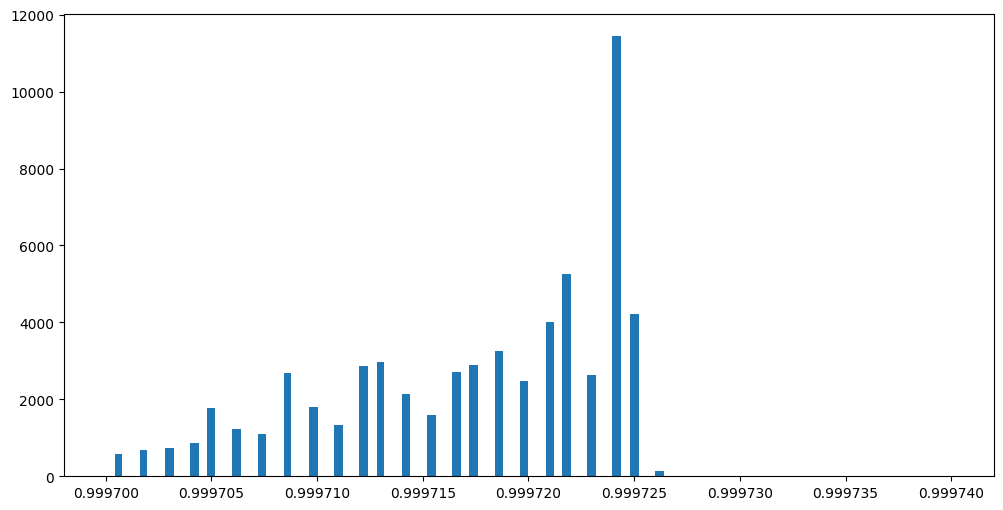

In [11]:
# Make the histogram wider
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
crs['probability_is_statistics'].hist(bins=100, range=(0.9997, 0.99974), grid=False)


# Print the max of all numbers < 1
print(crs['probability_is_statistics'][crs['probability_is_statistics'] < 1].max())

In [17]:
import numpy as np
thresholds = [round(x, 6) for x in np.arange(0.999726, 0.9997, -0.000001)]

thresholds

[0.999726,
 0.999725,
 0.999724,
 0.999723,
 0.999722,
 0.999721,
 0.99972,
 0.999719,
 0.999718,
 0.999717,
 0.999716,
 0.999715,
 0.999714,
 0.999713,
 0.999712,
 0.999711,
 0.99971,
 0.999709,
 0.999708,
 0.999707,
 0.999706,
 0.999705,
 0.999704,
 0.999703,
 0.999702,
 0.999701]

In [18]:
# Aggregate the the total of usd_disbursement grouped by year and make one line for each threshold 
def aggregate_by_threshold(df, thresholds):
    results = []
    for threshold in thresholds:
        # Filter the DataFrame based on the threshold
        filtered_df = df[df['probability_is_statistics'] >= threshold]
        
        # Group by year and sum the usd_disbursement 
        aggregated = filtered_df.groupby('year')['usd_disbursement'].sum().reset_index()
        
        # Add the threshold to the aggregated DataFrame
        aggregated['threshold'] = threshold
        
        results.append(aggregated)
    
    return pd.concat(results, ignore_index=True)

# Apply the aggregation function to the CRS DataFrame
aggregated_results = aggregate_by_threshold(crs, thresholds)

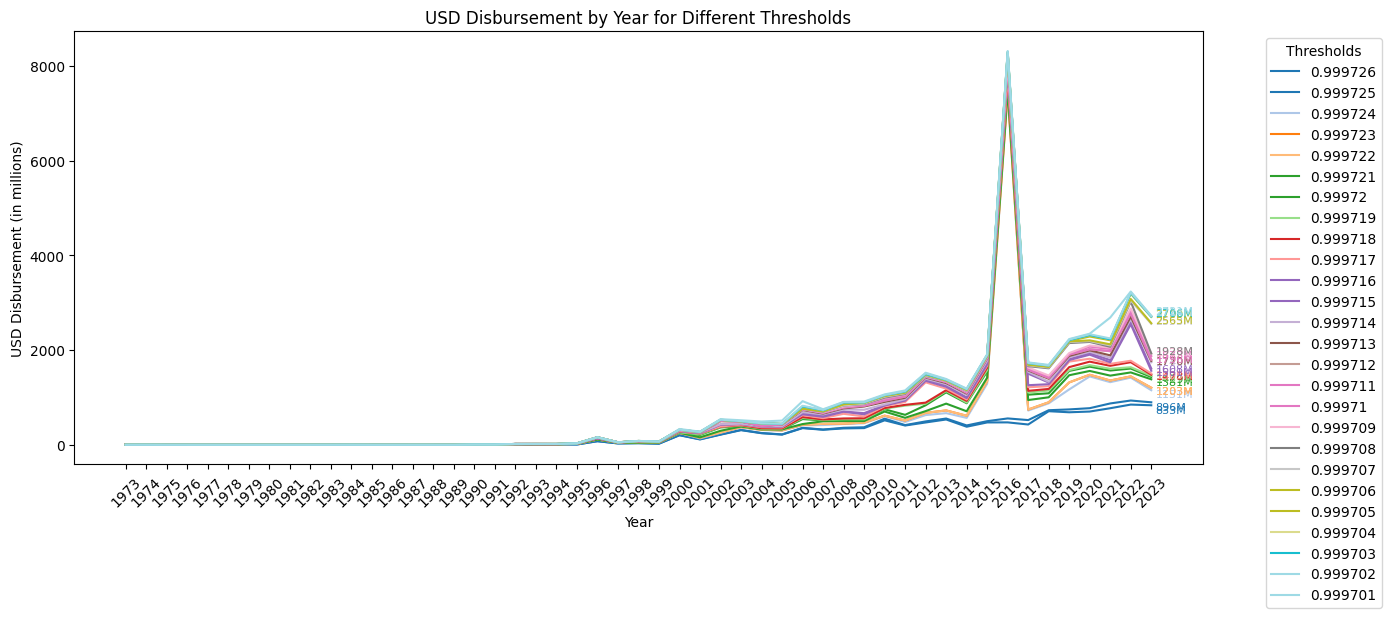

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14, 6))

# Use a qualitative colormap for distinct colors
cmap = plt.get_cmap('tab20', len(thresholds))
colors = [cmap(i) for i in range(len(thresholds))]

# To avoid overlap, stagger the annotation positions
offsets = np.linspace(-100, 100, len(thresholds))

for idx, threshold in enumerate(thresholds):
    threshold_data = aggregated_results[aggregated_results['threshold'] == threshold]
    plt.plot(threshold_data['year'], threshold_data['usd_disbursement'], label=f'{threshold}', color=colors[idx])
    # Annotate the last year value to the right of the line
    if not threshold_data.empty:
        last_row = threshold_data.iloc[-1]
        plt.text(
            last_row['year'] + 0.2,  # Slightly to the right
            last_row['usd_disbursement'] + offsets[idx],  # Stagger vertically
            f"{int(last_row['usd_disbursement'])}M",  # Format as millions
            va='center',
            fontsize=8,
            color=colors[idx]
        )

plt.title('USD Disbursement by Year for Different Thresholds')
plt.xlabel('Year')
plt.ylabel('USD Disbursement (in millions)')
plt.xticks(threshold_data['year'].unique())
plt.legend(title='Thresholds', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [30]:
# Output CRS for 2023
crs_2023 = crs[crs['year'] == 2023].copy()

# Reduce crs_2023 to only the columns we need
crs_2023 = crs_2023[['year', 'donor_name',
       'agency_name','recipient_name', 
       'region_name', 'usd_commitment',
       'usd_disbursement', 'usd_received', 'usd_commitment_defl',
       'usd_disbursement_defl', 'purpose_code','project_title', 'short_description', 'long_description',
       'text_mining_description', 'stat_keywords', 'stat_acronyms', 
       'probability_is_statistics']]

In [31]:
# Save crs_2023 to xlsx file
crs_2023.to_excel("../../data/output/crs_2023.xlsx", index=False)

In [32]:
# Output CRS for 2023
crs_2016 = crs[crs['year'] == 2016].copy()

# Reduce crs_2023 to only the columns we need
crs_2016 = crs_2016[['year', 'donor_name',
       'agency_name','recipient_name', 
       'region_name', 'usd_commitment',
       'usd_disbursement', 'usd_received', 'usd_commitment_defl',
       'usd_disbursement_defl', 'purpose_code','project_title', 'short_description', 'long_description',
       'text_mining_description', 'stat_keywords', 'stat_acronyms', 
       'probability_is_statistics']]

# Save crs_2023 to xlsx file
crs_2016.to_excel("../../data/output/crs_2016.xlsx", index=False)

In [33]:
# Output CRS for 2023
crs_2015 = crs[crs['year'] == 2015].copy()

# Reduce crs_2023 to only the columns we need
crs_2015 = crs_2015[['year', 'donor_name',
       'agency_name','recipient_name', 
       'region_name', 'usd_commitment',
       'usd_disbursement', 'usd_received', 'usd_commitment_defl',
       'usd_disbursement_defl', 'purpose_code','project_title', 'short_description', 'long_description',
       'text_mining_description', 'stat_keywords', 'stat_acronyms', 
       'probability_is_statistics']]

# Save crs_2023 to xlsx file
crs_2015.to_excel("../../data/output/crs_2015.xlsx", index=False)